# STUDIO 1 [17/08/26]
### Operations & Elements of Programming

In [ ]:
import math

def biggie_size(x):
    return x+4

def unbiggie_size(x):
    return x-4

def is_biggie_size(x):
    return x>4

def combo_price(x):
    if (x <= 4): #can use prev arguments like is_biggie_size()
        price = x * 1.17
    else:
        price = (x-4)*1.17 + 0.50
    return price

def empty_order():
    return 0

def add_to_order(x1, x2):
    return f"{x1}{x2}" #dont use strings they prefer integers(?)

def last_combo(x):
    return x % 10

def other_combos(x):
    return math.floor(x/10) #or u can do return x//10

In [ ]:
# EXTRA qns
import math

def discounted_price(q, c):
    return (c*0.9 if q%2==0 else c*0.9)

def last_n_combos(x, y):
    return x % (10**y)

def first_n_combos(order, n):
    total_digits = math.floor(math.log10(order)) +1 # well uhh on source academy u do math_floor and math_log10 i hate source >:()
    return order // (10 ** (total_digits-n))

def max_num(a, b, c):
    return (a if a >= c else c) if a >= b else (b if b >= c else c) #don't use multiple returns it dont work

In [ ]:
# interesting observation (???)

def test1():
    return 0 if 4>3 else 1/0 # does not return an error as the program does not read past the predicate as it is tru

# but this is not true for "syntax" issues such as a variable that was not defined
def test2():
    return 0 if 4>3 else x # returns an error as x is not defined

In [ ]:
# Working with numbers cheatsheet
n = 123456789, k = 3
import math

n % 10 #getting last digit
n % (10**k) # getting last k digits
n // 10 # removing last digit
n // (10**k) # removing last k digits
math.floor(math.log10(n)) + 1 # getting number of digits in n

len(str(n)) #DONT do this profs dont like changing data type cuz its "not rigorous enough"

# LECTURE 3 [19/08/26]

In [ ]:
# recursionnnnnn

# for example, if we wanted to find the factorial of a number n

def factorial(n):
    return 1 if n==0 else factorial(n-1)

this is an example of a <u>recursive process</u> because the function is called recursively

a recursion function can also be iterative... for example...

In [ ]:
def factorial(n):
    return iter(1,1,n)

def iter(product, counter, n):
    return (
        product
        if counter > n
        else iter(product * counter, counter + 1, n) #comuptes directly as every time

- <u>recursive</u> if <b>deferred operations</b> accumulate

- <u>iterative</u> if they don't

the operations get deferred because a certain value that is needed hasnt already been computed yet

<u>applicative order</u> --> python "evaluates the arguments of a function first"

In [ ]:
def f(x, y):
    return y if x == 0 else f(x-1, y+1) # y is called an "accumulator"

print(f(4, 5))

9


# LECTURE 4 [21/08/26]

In [ ]:
# the fibo function grows very very quickly
# eg the recursive version

def fibo(n):
    return n if n <= 1 else fibo(n-1) + fibo(n-2)
# number of leaves in tree increases exponentially

# the iterative version is "better" due to less deferred operations
def fib(n):
    return fib_iter(1, 0, n)

def fib_iter(a, b, count):
    return b if count == 0 else fib_iter(a+b, a, count-1)

fib(11)

89

how do we compare? –> time & space

number of deferred operations ?? time and space and number of deferred operations increase linearly in a factorial function <br><br>
<b>big Θ notation :</b> function r has order of growth Θ(g(n)) if there are <u>positive</u> constants k<sub>1</sub> and k<sub>2</sub> such that k<sub>1</sub>•g(n) ≤ r(n) ≤ k<sub>2</sub>•g(n) for all n > n<sub>0</sub> <br>
<b>big O notation :</b> function r has order of growth O(g(n)) if there is a <u>positive</u> constant k such that r(n) ≤ k•g(n) for all n > n<sub>0</sub> <br>
<b>big Ω notation :</b> function r has order of growth O(g(n)) if there is a <u>positive</u> constant k such that k•g(n) ≤ r(n) for all n > n<sub>0</sub> <br><br>
common growth terms
- logn, n, nlogn, n<sup>2</sup>, n<sup>3</sup>, 2<sup>n</sup>
- pick the tightest bound (worst case)

In [ ]:
def factorial(n):
    return fact_iter(1, 1, n)

def fact_iter(product, counter, max_count):
    return (product
            if counter > max_count
            else fact_iter(counter * product, counter + 1, max_count)) # time complexity = O(n)

# now suppose, a is any number.
# and n is a power of two (i.e. 1, 2, 4, 8, 16, ...)

def f(a, n):
    return a if n == 1 else f(2 * a, n / 2) # time complexity = O(logn)


# LECTURE 5 [26/08/26]
### Higher-order Functions; Scope of Names

tree recursion vs linear recursion <br>
e.g. for the rune reading fractal example <br>

```
from rune import beside, stack

def fractal_1(rune, n):
    return (rune if n == 1
            else beside(rune,
                stack(fractal_1(rune, n - 1),
                      fractal_1(rune, n - 1))))
```
<br>
we can avoid this by defining a variable within the function for "intermediate values" so it only has to compute once
<br>

```
from rune import beside, stack

def fractal_2(rune, n):
    if n == 1:
        return rune
    else:
        smaller_frac = fractal_2(rune, n - 1)
        return beside(rune, stack(smaller_frac, smaller_frac))
```


"conditional expression" --> what they call the onleine ternary operator stuff <br>
"conditional statements" --> the if/else blocks

OKAY PRACTICE TIME!!! <br><br>
try to create a coin counter function to return the number of ways u can come up with a certain value of cents using coins! <br>
⭐️ hint !! : create a helper function for the denominations

In [72]:
def cc(amt, cointype):
    def denom(cointype):
        return (
            5 if cointype == 1
            else 10 if cointype == 2
            else 20 if cointype == 3
            else 50 if cointype == 4
            else 100 if cointype == 5
            else 0
        )

    return (1 if amt == 0 
            else 0 if (amt < 0 or cointype == 0)
            else cc(amt-denom(cointype), cointype-1) + cc(amt, cointype-1) # pascal's identity!
            )

cc(120, 5)

1

In [73]:
# kinda cool sum of integers and cubes method (?)

def cube(x):
    return x*x*x

def sum_of_int(a, b):
    return 0 if a>b else a + sum_of_int(a+1, b)

def cube_of_int(a, b): # return sum of cubes of every other integer
    return 0 if a > b else cube(a) + cube_of_int(a+2, b)

cube_of_int(1, 3)

28

Lambda expressions! <br>
basically like a shorthand way of writing a function 

In [74]:
# e.g. 
def cube_1(x):
    return x*x*x

# is similar to

cube = lambda x : x*x*x
print(cube(2))

8


In [75]:
# emm idk what to call this?? functional abstraction??

def make_adder(x):
    def adder(y):
        return x+y
    return adder

make_adder(4)(5) #yup u can do this ig, i didnt know that tbh

9

scope of names <br>
sometimes same variable is declared at different places and it seems to work <br>
rule to apply: <u>closest surrounding declaration</u> -> when choosing which variable its referred to, it looks for the variable that was declared the closest <br>

In [ ]:
# HOOOOLYYY SHIIIITTTT this path made me wanna kms

def sum(term, a, next, b):
    return (0 if a > b
            else term(a) + sum(term, next(a), next, b))

def sum_odd(n): # sum of the first n odd natural numbers
    a = 1
    b = n*2-1
    next = lambda x : x+2
    term = lambda y : y
    return sum(term, a, next, b)

def sum_odd_lte(n): # sum the first n odd numbers less than or equal to n.
    a = 1
    b = n
    next = lambda x : x+2
    term = lambda y : y
    return sum(term, a, next, n)

# GENERALISATION (TS KILLED ME BRUH)
def accumulate(combiner, term, a, next, b, base):
    return (base if a > b 
    else combiner(term(a), accumulate(combiner, term, next(a), next, b, base))
    )

# Example uses:

def sum(term, a, next, b):
    return accumulate(lambda x, y: x + y, term, a, next, b, 0)

def product(term, a, next, b):
    return accumulate(lambda x, y: x * y, term, a, next, b, 1)

def fact(n):
    return product(lambda x: x, 1, lambda x: x + 1, n)

# i need more practice on this bro

### Functional Expressionism!! [Quest]
#### Question 1<br>
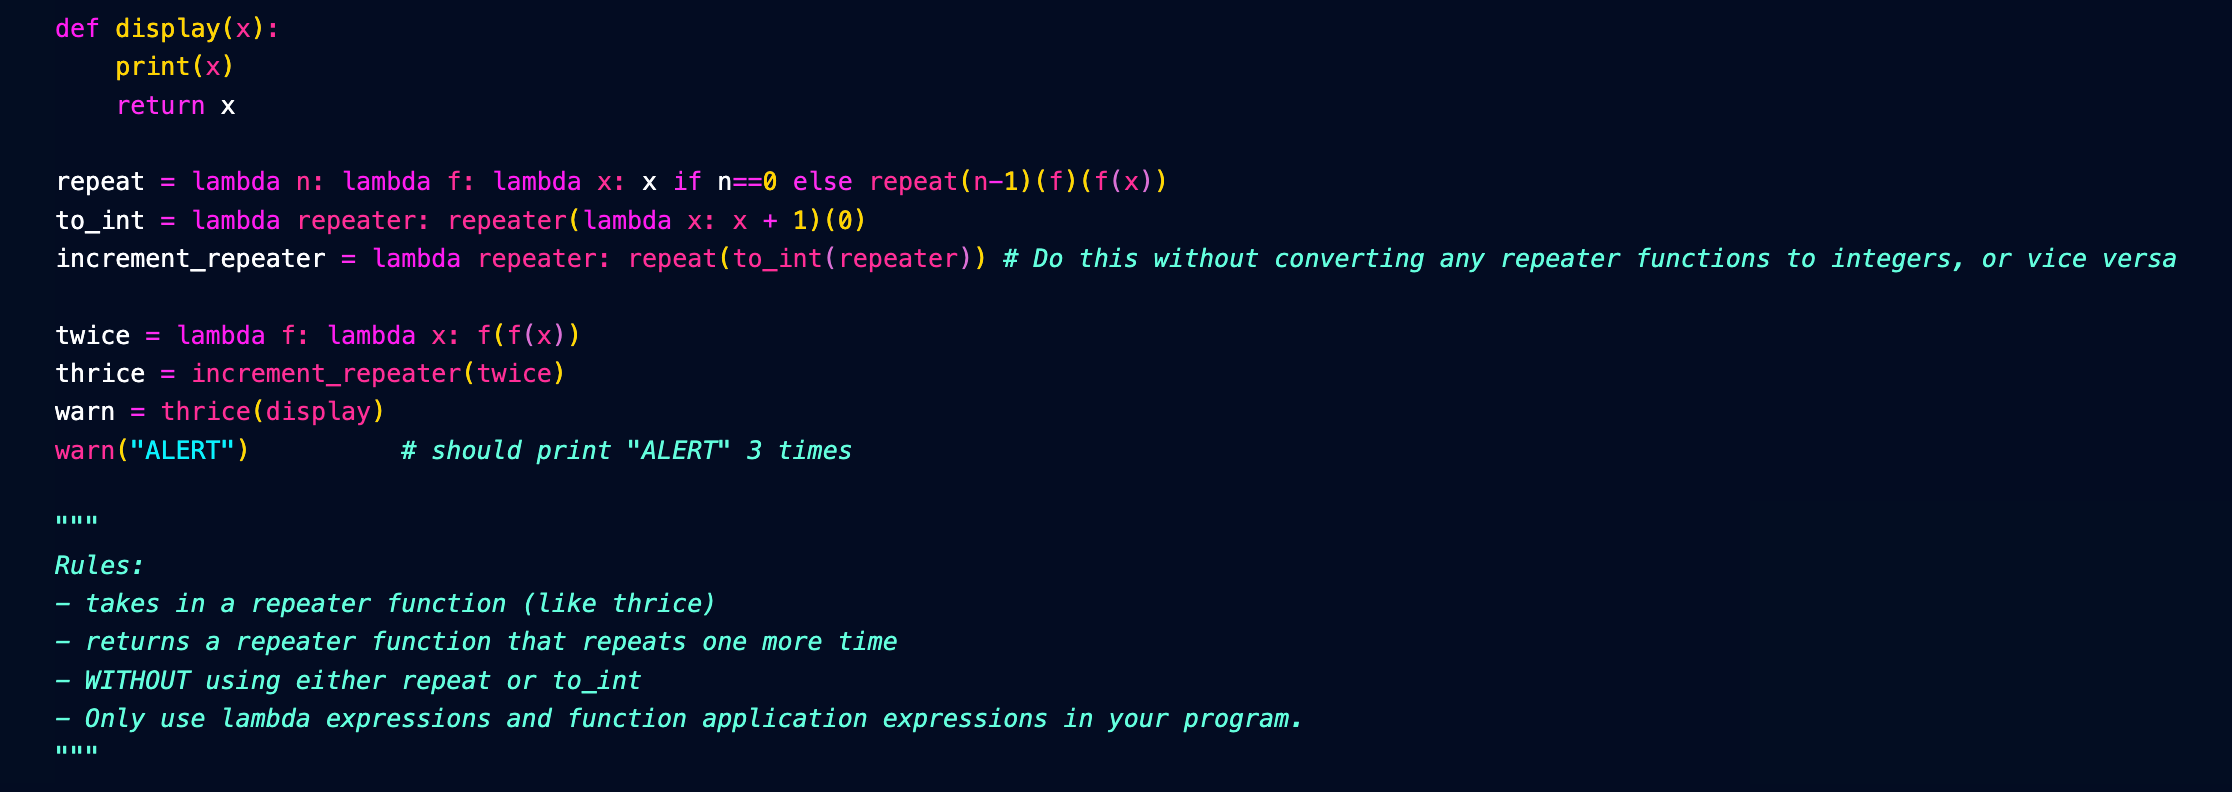

In [2]:
def display(x):
    print(x)
    return x

increment_repeater = lambda repeater: lambda f: lambda x: f(repeater(f)(x))
# i kept trying to do f(repeater(x)) but see that repeater takes in 2 parameters f and x so they must be given separately ykwim

twice = lambda f: lambda x: f(f(x))
thrice = increment_repeater(twice)
fourtimes = increment_repeater(thrice)
warn = fourtimes(display)
warn("ALERT")




ALERT
ALERT
ALERT
ALERT


'ALERT'

#### Question 2
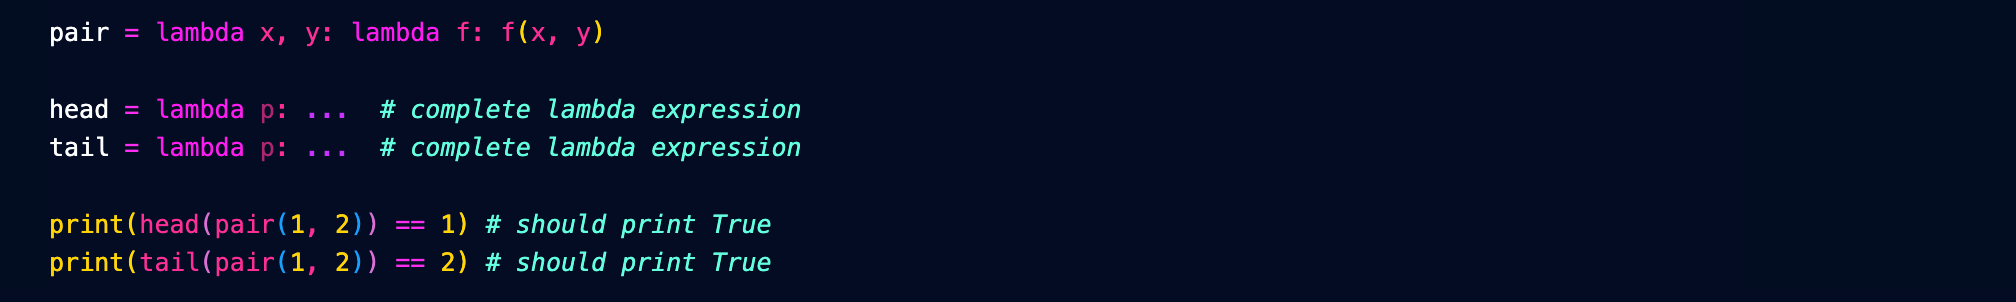

In [5]:
pair = lambda x, y: lambda f: f(x, y)

head = lambda p: p(lambda x, y: x)
tail = lambda p: p(lambda x, y: y)

print(head(pair(1, 2)) == 1)
print(tail(pair(1, 2)) == 2)

True
True


#### Question 3
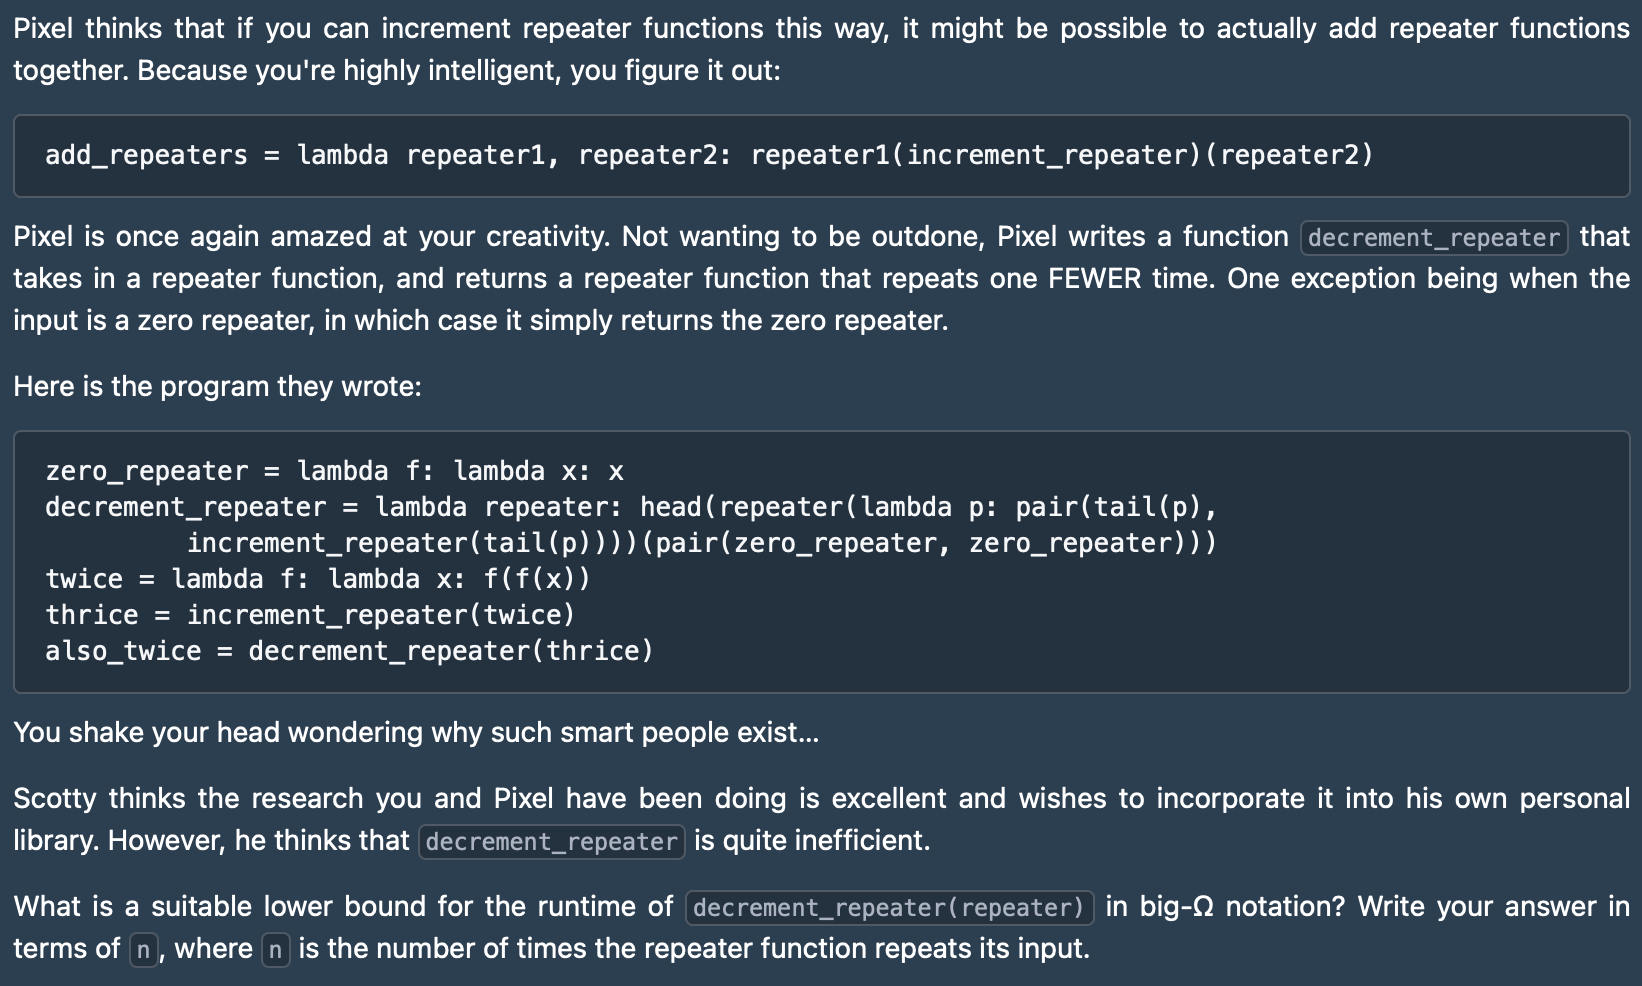

In [6]:
zero_repeater = lambda f: lambda x: x


decrement_repeater = lambda repeater: head(
    repeater(                               # this part gets executed n times since it's passing into repeater
        lambda p: pair(                     # how this works : p start is (zero_rep, zero_rep) -> (zero, once) -> (once, twice) -> (twice, thrice)
            tail(p),                        # basically this gets repeated n times (repeater=n) and the head is taken bec the head will be n-1
            increment_repeater(tail(p)))    # tail(p) only runs once per round. increment_repeater also runs once per round? so is big-Ω notation just n??
    )
    (pair(
        zero_repeater, # base case ig
        zero_repeater
    )
    )
)


twice = lambda f: lambda x: f(f(x))
thrice = increment_repeater(twice)
also_twice = decrement_repeater(thrice)

ALERT
ALERT


'ALERT'

#### Question 4
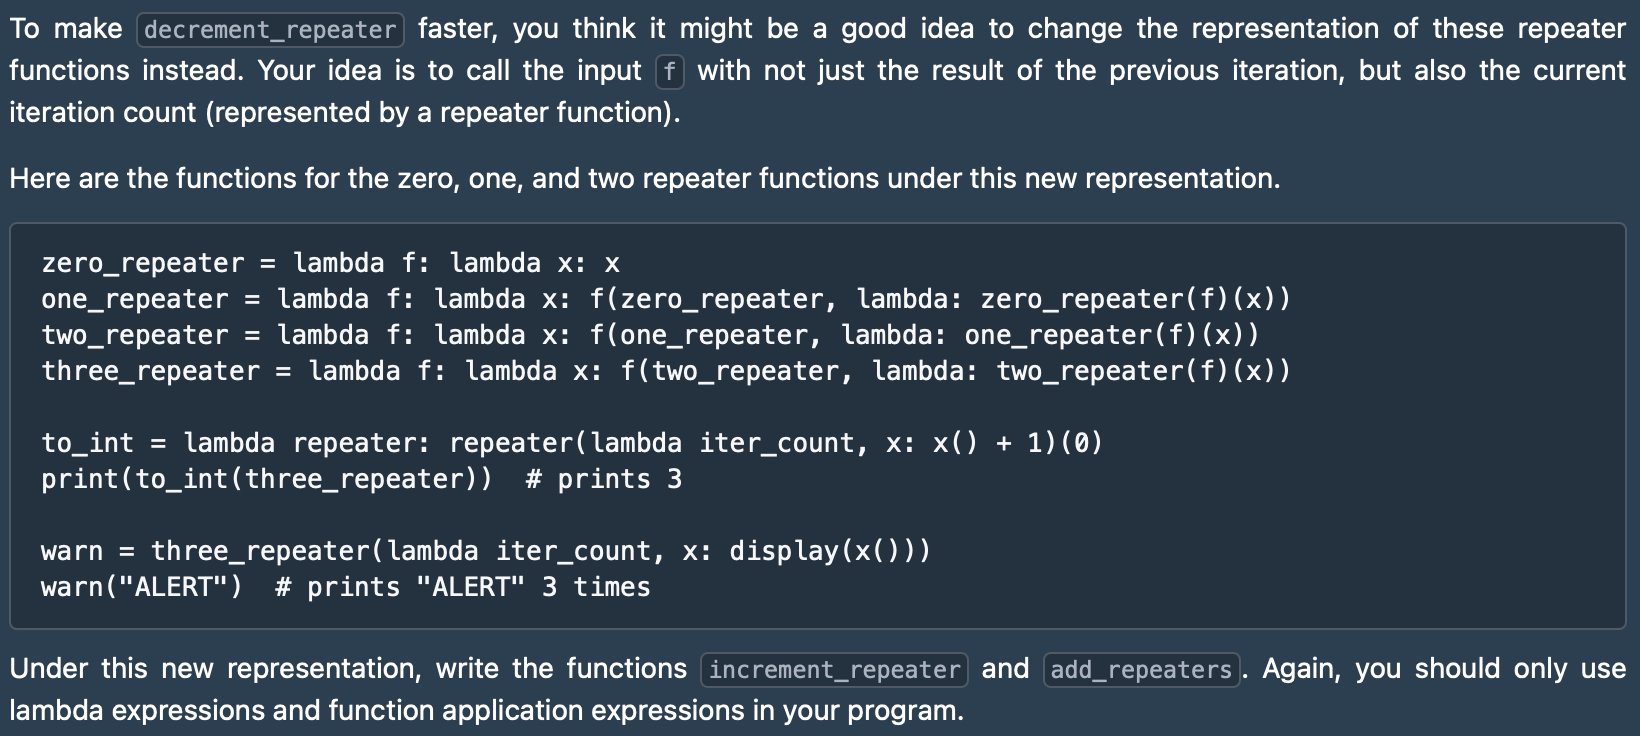

In [ ]:
zero_repeater = lambda f: lambda x: x
increment_repeater = lambda repeater: lambda f: lambda x: f(repeater(f)(x))
one_repeater = increment_repeater(zero_repeater)
two_repeater = increment_repeater(one_repeater)
three_repeater = increment_repeater(two_repeater)

to_int = lambda repeater: repeater(lambda iter_count, x: x() +1)(0)

add_repeaters = lambda repeater1, repeater2: repeater1(increment_repeater)(repeater2)

print(to_int(add_repeaters(two_repeater, three_repeater)))  # should print 5

5


#### Question 5
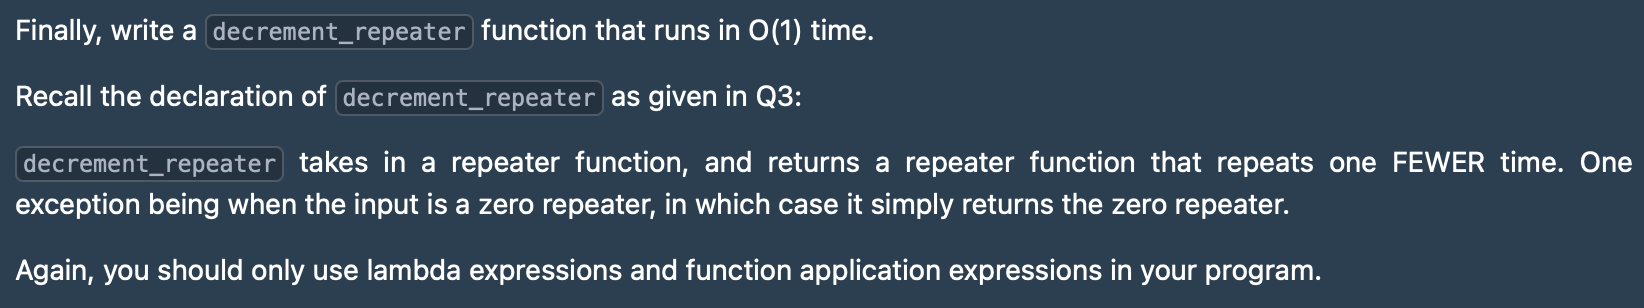

In [42]:
zero_repeater = lambda f: lambda x: x
one_repeater = lambda f: lambda x: f(zero_repeater, lambda: zero_repeater(f)(x))
two_repeater = lambda f: lambda x: f(one_repeater, lambda: one_repeater(f)(x))
three_repeater = lambda f: lambda x: f(two_repeater, lambda: two_repeater(f)(x))

to_int = lambda repeater: repeater(lambda iter_count, x: x() +1)(0)
decrement_repeater = lambda repeater: repeater(lambda iter_count, x: iter_count)(zero_repeater)

print(to_int(decrement_repeater(three_repeater)))  # should print 2

2


# Lecture 6 [28/08/26]
logical operators (and/or)
basically unlike a real binary operator, the <u>right hand expression is not always evaluated</u>! <br>
this is bec for P or Q, if P is true then P∨Q is true for any Q <br>
similarly if P is false, P∧Q is false for any Q <br>

In [43]:
# e.g.
def boom():
    return 1/0 # wld crash if it ran

print(False and boom())
print(True or boom()) # runs without crashing bec the RHS expression is ignored

# this is called "laziness"

False
True


In [44]:
# dont test these it wont run lmao

from curve import make_point, draw_connected, x_of, y_of, draw_connected_full_view_proportional
import math

p = make_point(1, 1)

def print_point(p):
    print("point: ", x_of(p), y_of(p))

def line_with(m, h):
    return lambda t: make_point(t, m*t+h)
    

def unit_circle(t):
    return make_point(
        math.cos(2 * math.pi * t),
        math.sin(2 * math.pi * t)
        )

def spiral_one(t):
    p = unit_circle(t)
    return make_point(t * x_of(p), t * y_of(p))

def spiral(rev):
    def spiral_helper(t):
        p = unit_circle((t*rev) % 1)
        return make_point(t* x_of(p), t* y_of(p))
    return spiral_helper

#draw_connected_full_view_proportional(2000)(spiral(20))
#draw_connected_full_view_proportional(100)(unit_circle)
#draw_connected_full_view_proportional(20)(line_with(2, 3)) #the number refers to the number of points this runs thru


ModuleNotFoundError: No module named 'curve'